# Version 3.0

## Libraries and imports

In [35]:
# Libraries
import sys
sys.path.append('..')
from feature_selection import data_feature_selection, split_data, split_data_3way, data_feature_selection_3way


import numpy as np
import pandas as pd
import time
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from os import scandir
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
import itertools

#import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
# Get the dataset
df_ml = pd.read_csv("../../data/processed/DatasetMaster.csv")
df_ml.columns


Index(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'runoff', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'alcaldia', 'tema_solicitud',
       'severidad', 'incident', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'soil_moisture_0_to_7cm_mean_3h', 'soil_moisture_7_to_28cm_mean_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_7_to_28cm_mean_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'soil_moisture_0_to_7cm_mean_12h', 'soil_moisture_7_to_28cm_mean_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'soil_moisture_0_to_7cm_mean_24h', 'soil_moisture_7_to_28cm_mean_24h',
       'relative_humidity_2m_mean_24h'],
      dtype='str')

In [37]:
# Split data function
X_train, X_test, y_train, y_test = split_data(df_ml)

In [38]:
# Feature selection
X_train, X_test = data_feature_selection(X_train, X_test)

Original Feature Count: 48
Cleaned Feature Count:  37


Use StandardScaler to normalize the values

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Create sequences for temporal models. We use `window_size=24` because the data is hourly.

In [40]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [41]:
window_size = 24
X_train_tcn, y_train_tcn = create_sequences(X_train_scaled, y_train, window_size)
X_test_tcn, y_test_tcn = create_sequences(X_test_scaled, y_test, window_size)

print(X_train_tcn.shape)
print(y_train_tcn.shape)

(854287, 24, 37)
(854287,)


We need to calculate class weights in order to train the model using balanced weights, compensating for the class imbalance between flood and non-flood events.

In [42]:
classes = np.unique(y_train_tcn)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_tcn
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5675247095900713), np.int64(1): np.float64(4.202348392428476)}


## Model creation

In [43]:
# Build TCN residual block
def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate):

    # Save the original input for the residual connection
    shortcut = x

    # Apply a causal temporal convolution to learn temporal patterns
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(x)

    # Normalize activations to stabilize training
    x = BatchNormalization()(x)

    # Apply non-linearity to learn complex relationships
    x = Activation("relu")(x)

    # Randomly deactivate neurons to reduce overfitting
    x = Dropout(dropout_rate)(x)

    # Apply a second temporal convolution for deeper feature extraction
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(x)

    # Normalize the second convolution output
    x = BatchNormalization()(x)

    # Adjust shortcut dimensions if the number of channels changed
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same"
        )(shortcut)

    # Combine learned features with the original input using a residual connection
    x = Add()([x, shortcut])

    # Apply final activation after the residual merge
    x = Activation("relu")(x)

    # Return the transformed temporal representation
    return x

In [44]:
# Build TCN model architecture
def build_tcn_model(
    window_size,
    n_features,
    filters=64,
    kernel_size=3,
    dropout_rate=0.3,
    dense_units=32
):

    # Define the input shape as (timesteps, features)
    inputs = Input(shape=(window_size, n_features))

    # Learn short-term temporal patterns using dilation rate 1
    x = residual_tcn_block(
        inputs,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=1,
        dropout_rate=dropout_rate
    )

    # Learn medium-range temporal dependencies using dilation rate 2
    x = residual_tcn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=2,
        dropout_rate=dropout_rate
    )

    # Learn longer temporal dependencies using dilation rate 4
    x = residual_tcn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=4,
        dropout_rate=dropout_rate
    )

    # Compress the temporal sequence into a single feature vector
    x = GlobalAveragePooling1D()(x)

    # Learn high-level non-linear combinations of temporal features
    x = Dense(dense_units, activation="relu")(x)

    # Apply dropout regularization before the final prediction
    x = Dropout(dropout_rate / 2)(x)

    # Output the probability of a flood event
    outputs = Dense(1, activation="sigmoid")(x)

    # Build the complete TCN model
    model = Model(inputs, outputs)

    # Configure training settings for binary classification
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model
    return model

In [45]:
# Initialize TCN model
n_features = X_train_tcn.shape[2]

tcn_model = build_tcn_model(
    window_size=window_size,
    n_features=n_features,
    filters=64,
    kernel_size=3,
    dropout_rate=0.3,
    dense_units=32
)

tcn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 37)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 24, 64)    │      7,168 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 24, 64)    │          0 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 24, 64)    │     12,352 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 24, 64)    │      2,432 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 24, 64)    │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 24, 64)    │     12,352 │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 24, 64)    │          0 │ activation_14[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 24, 64)    │     12,352 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 24, 64)    │          0 │ add_7[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 24, 64)    │     12,352 │ activation_15[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 75,009 (293.00 KB)

 Trainable params: 74,241 (290.00 KB)

 Non-trainable params: 768 (3.00 KB)

### Train the model

In [46]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_tcn = tcn_model.fit(
    X_train_tcn,
    y_train_tcn,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 355s 31ms/step - accuracy: 0.7455 - loss: 0.4765 - val_accuracy: 0.7419 - val_loss: 0.4764
Epoch 2/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 332s 31ms/step - accuracy: 0.7612 - loss: 0.4558 - val_accuracy: 0.7601 - val_loss: 0.4747
Epoch 3/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 329s 31ms/step - accuracy: 0.7663 - loss: 0.4482 - val_accuracy: 0.7557 - val_loss: 0.4786
Epoch 4/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 323s 30ms/step - accuracy: 0.7680 - loss: 0.4439 - val_accuracy: 0.7766 - val_loss: 0.4671
Epoch 5/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 444s 42ms/step - accuracy: 0.7705 - loss: 0.4409 - val_accuracy: 0.7754 - val_loss: 0.4684
Epoch 6/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 361s 34ms/step - accuracy: 0.7726 - loss: 0.4390 - val_accuracy: 0.7440 - val_loss: 0.4922
Epoch 7/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 326s 31ms/step - accuracy: 0.7731 - loss: 0.4364 - val_accuracy: 0.7200 - val_loss: 0.5599
Epoch 8/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 370s 35ms/s

### Evaluate the model

In [47]:
y_scores_tcn = tcn_model.predict(X_test_tcn).ravel()

threshold = 0.40
y_pred_tcn = (y_scores_tcn >= threshold).astype(int)

print(classification_report(y_test_tcn, y_pred_tcn))
print("PR-AUC:", average_precision_score(y_test_tcn, y_scores_tcn))

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step
              precision    recall  f1-score   support

           0       0.86      0.73      0.79    105180
           1       0.62      0.78      0.69     58953

    accuracy                           0.75    164133
   macro avg       0.74      0.76      0.74    164133
weighted avg       0.77      0.75      0.76    164133

PR-AUC: 0.7392374516693796


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step


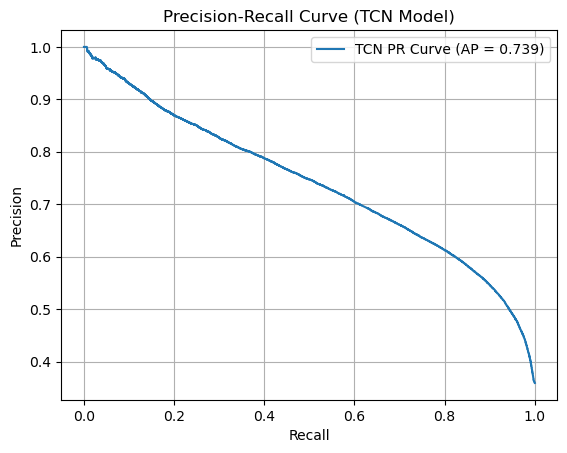

In [48]:
# Get model probabilities for TCN
y_scores_tcn = tcn_model.predict(X_test_tcn).ravel()

# Calculate precision-recall curve
precision_tcn, recall_tcn, thresholds_tcn = precision_recall_curve(
    y_test_tcn,
    y_scores_tcn
)

# Calculate PR-AUC / Average Precision
ap_tcn = average_precision_score(y_test_tcn, y_scores_tcn)

# Plot
plt.figure()
plt.plot(recall_tcn, precision_tcn, label=f"TCN PR Curve (AP = {ap_tcn:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (TCN Model)")
plt.legend()
plt.grid()
plt.show()

In [49]:
threshold = 0.40
y_pred_tcn = (y_scores_tcn >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_tcn, y_pred_tcn).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 76,960
False Positive (predicted incident, was safe): 28,220 false alarms)
False Negatives (predicted safe, was an incident) 12,737 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 46,216


In [50]:
def optimize_recall_tcn(modelo, X_test_tcn, y_test_tcn, new_threshold=0.40):

    # The TCN already outputs the probability of class 1 because
    # the final layer uses Dense(1, activation="sigmoid")
    probabilities = modelo.predict(X_test_tcn).ravel()

    # Apply new threshold
    adjusted_predictions = (probabilities >= new_threshold).astype(int)

    print("New Threshold report:")
    print(classification_report(y_test_tcn, adjusted_predictions))

    # Extract confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_tcn, adjusted_predictions).ravel()

    print("Adjusted Confusion matrix")
    print(f"True negatives: {tn:,}")
    print(f"False Positive (false alarms): {fp:,} <- may increase as the cost of higher recall")
    print(f"False Negatives  (danger cases): {fn:,} <- should decrease")
    print(f"True Positives (captured incidents): {tp:,} <- should increase")

In [51]:
predicciones_optimas = optimize_recall_tcn(tcn_model, X_test_tcn, y_test_tcn, new_threshold=0.40)

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step
New Threshold report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79    105180
           1       0.62      0.78      0.69     58953

    accuracy                           0.75    164133
   macro avg       0.74      0.76      0.74    164133
weighted avg       0.77      0.75      0.76    164133

Adjusted Confusion matrix
True negatives: 76,960
False Positive (false alarms): 28,220 <- may increase as the cost of higher recall
False Negatives  (danger cases): 12,737 <- should decrease
True Positives (captured incidents): 46,216 <- should increase


In [52]:
# Function to tune TCN hyperparameters using automatic validation split
def hyperparameter_tuning_tcn(
    X_train_tcn,
    y_train_tcn,
    window_size,
    threshold=0.40
):

    # Get number of input features per timestep
    n_features = X_train_tcn.shape[2]

    # Define validation size for metric calculation
    val_size = int(len(X_train_tcn) * 0.2)

    # Extract automatic validation subset
    X_val_tcn = X_train_tcn[-val_size:]
    y_val_tcn = y_train_tcn[-val_size:]

    # Define hyperparameter search space
    parameters_space = {
        "filters": [32, 64],
        "dense_units": [16, 32],
        "dropout_rate": [0.2, 0.3],
        "batch_size": [64]
    }

    # Generate all hyperparameter combinations
    combinations = list(itertools.product(
        parameters_space["filters"],
        parameters_space["dense_units"],
        parameters_space["dropout_rate"],
        parameters_space["batch_size"]
    ))

    # Store tuning results
    results = []

    # Start execution timer
    start = time.time()

    # Train one model per hyperparameter combination
    for filters, dense_units, dropout_rate, batch_size in combinations:

        # Print current configuration
        print(
            f"Training: TCN={filters}, "
            f"Dense={dense_units}, "
            f"Dropout={dropout_rate}, "
            f"Batch={batch_size}"
        )

        # Build model with current hyperparameters
        model = build_tcn_model(
            window_size=window_size,
            n_features=n_features,
            filters=filters,
            kernel_size=3,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )

        # Stop training when validation loss stops improving
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        # Train model using automatic validation split
        history_tcn = model.fit(
            X_train_tcn,
            y_train_tcn,
            validation_split=0.2,
            epochs=20,
            batch_size=batch_size,
            callbacks=[early_stop],
            class_weight=class_weights,
            shuffle=False,
            verbose=0
        )

        # Predict probabilities on validation subset
        probabilities = model.predict(X_val_tcn).ravel()

        # Convert probabilities into binary predictions
        predictions = (probabilities >= threshold).astype(int)

        # Compute validation metrics
        pr_auc = average_precision_score(y_val_tcn, probabilities)
        recall = recall_score(y_val_tcn, predictions, zero_division=0)
        f1 = f1_score(y_val_tcn, predictions, zero_division=0)

        # Save current experiment results
        results.append({
            "filters": filters,
            "dense_units": dense_units,
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "epochs_trained": len(history_tcn.history["loss"]),
            "pr_auc": pr_auc,
            "recall": recall,
            "f1": f1,
            "model": model
        })

    # End execution timer
    end = time.time()

    # Sort results by validation PR-AUC
    results = sorted(results, key=lambda x: x["pr_auc"], reverse=True)

    # Select best configuration
    best_result = results[0]

    # Convert execution time to minutes
    minutos = (end - start) / 60

    # Print tuning summary
    print(f"Tiempo de ejecución: {minutos:.2f} minutos")
    print("LA ARQUITECTURA GANADORA ES:")
    print(f"-> filters: {best_result['filters']}")
    print(f"-> dense_units: {best_result['dense_units']}")
    print(f"-> dropout_rate: {best_result['dropout_rate']}")
    print(f"-> batch_size: {best_result['batch_size']}")
    print(f"-> epochs_trained: {best_result['epochs_trained']}")
    print(f"\nMejor Score (PR-AUC) en validación: {best_result['pr_auc']:.4f}")
    print(f"Recall en validación: {best_result['recall']:.4f}")
    print(f"F1 en validación: {best_result['f1']:.4f}")

    # Return best model and tuning results
    return best_result["model"], results

In [ ]:
# Perform TCN hyperparameter tuning using validation performance
hyperparameterized_tcn_model, tcn_tuning_results = hyperparameter_tuning_tcn(
    X_train_tcn,
    y_train_tcn,
    window_size=window_size,
    threshold=0.40
)

Training: TCN=32, Dense=16, Dropout=0.2, Batch=64


In [ ]:
def final_model_evaluation_tcn(modelo_campeon, X_test_tcn, y_test_tcn, umbral=0.40):
    print("--- STARTING FINAL EVALUATION TCN ON FUTURE DATA (2025) ---")

    # The TCN already outputs probabilities through the sigmoid layer
    probabilidades = modelo_campeon.predict(X_test_tcn).ravel()

    # Apply the selected decision threshold
    predicciones_finales = (probabilidades >= umbral).astype(int)

    print(f"\nPERFORMANCE REPORT (UMBRAL: {umbral * 100:.0f}%)")
    print("=" * 50)
    print(classification_report(y_test_tcn, predicciones_finales))

    # Final confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_tcn, predicciones_finales).ravel()

    print("\nFINAL CONFUSION MATRIX:")
    print(f"True negatives (safe hours): {tn:,}")
    print(f"Falsos Positivos (false alarms): {fp:,}")
    print(f"False negatives (missed incidents): {fn:,}")
    print(f"True positives (captured incidents): {tp:,}")

    # Métricas de negocio
    recall_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0

    print("\nBUSINESS METRICS (CIVIL PROTECTION):")
    print(f"-> Capture rate (Recall): {recall_final * 100:.1f}% de las inundaciones fueron detectadas.")
    print(f"-> Precision de Alarma: {precision_final * 100:.1f}% de las alertas fueron reales.")

    return {
        "threshold": umbral,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "recall": recall_final,
        "precision": precision_final
    }

In [ ]:
tcn_final_results = final_model_evaluation_tcn(
    hyperparameterized_tcn_model,
    X_test_tcn,
    y_test_tcn,
    umbral=0.40
)

--- INICIANDO EVALUACIÓN FINAL TCN SOBRE EL FUTURO (2025) ---
5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

REPORTE DE RENDIMIENTO (UMBRAL: 40%)
              precision    recall  f1-score   support

           0       0.83      0.79      0.81    105180
           1       0.66      0.70      0.68     58953

    accuracy                           0.76    164133
   macro avg       0.74      0.75      0.75    164133
weighted avg       0.77      0.76      0.76    164133


MATRIZ DE CONFUSIÓN DEFINITIVA:
Verdaderos Negativos (Días/Horas Pacíficas): 83,540
Falsos Positivos (Falsas Alarmas): 21,640
Falsos Negativos (Desastres Omitidos): 17,409
Verdaderos Positivos (Desastres Prevenidos): 41,544

MÉTRICAS DE NEGOCIO (PROTECCIÓN CIVIL):
-> Tasa de Captura (Recall): 70.5% de las inundaciones fueron detectadas.
-> Precisión de Alarma: 65.8% de las alertas fueron reales.


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


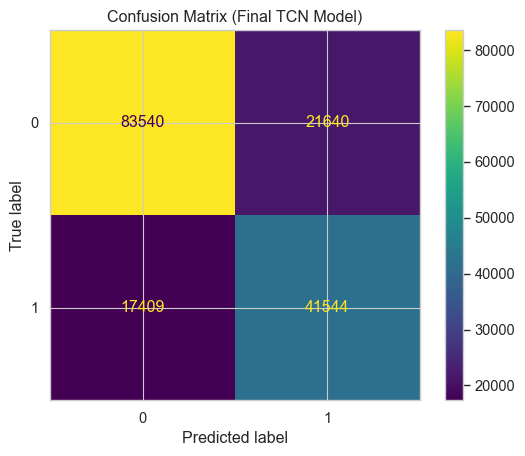

In [ ]:
y_pred_final_tcn = (
    hyperparameterized_tcn_model
    .predict(X_test_tcn)
    .ravel() >= 0.40
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test_tcn,
    y_pred_final_tcn
)

plt.title("Confusion Matrix (Final TCN Model)")
plt.show()

Unlike XGBoost, the TCN model does not provide direct feature-importance metrics because it learns distributed temporal representations.

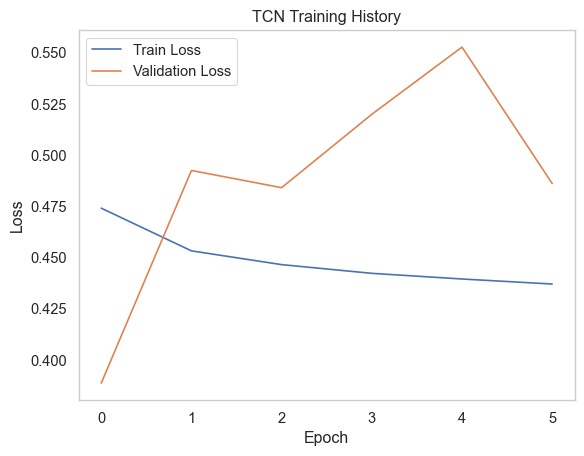

In [ ]:
plt.plot(history_tcn.history["loss"], label="Train Loss")
plt.plot(history_tcn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TCN Training History")

plt.legend()
plt.grid()

plt.show()

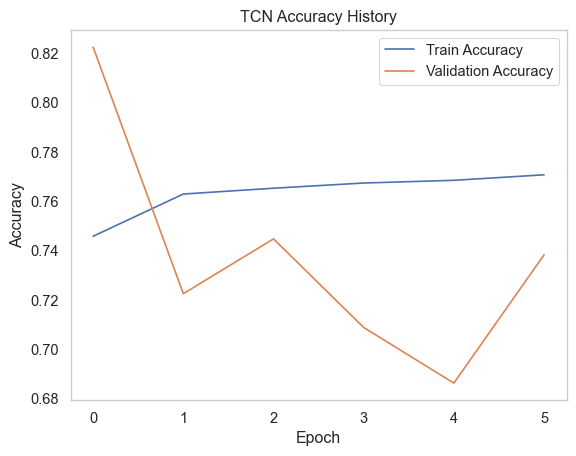

In [ ]:
plt.plot(history_tcn.history["accuracy"], label="Train Accuracy")
plt.plot(history_tcn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TCN Accuracy History")

plt.legend()
plt.grid()

plt.show()